<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## **Desafio, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/jul_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.

Importo el dataset utilizado por el traductor desarrollado en clase y utilizo el doble de oraciones y el doble de longitud máxima de las oraciones:

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("./spa-eng/spa.txt") as f:
    lines = f.read().split("\n")[:-1]

In [3]:
MAX_NUM_SENTENCES = 20000

np.random.seed(40)
np.random.shuffle(lines)

Aplico tokenización y padding:

In [4]:
input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Oraciones cargadas: {len(input_sentences)}")

Oraciones cargadas: 20000


In [6]:
MAX_VOCAB_SIZE = 8000

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

#Solo se tomarán en cuenta las 8000 palabras más frecuentes y se eliminan signos de puntuación
output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)

output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

max_input_len = 40
max_out_len   = 42

print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")
print(f"max_input_len={max_input_len}  max_out_len={max_out_len}")

encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

Vocabulario EN: 6812 | ES: 11323
max_input_len=40  max_out_len=42


Utilizo la misma función que el traductor desarrollado en clase para obtener un tf.data.Dataset, que genera batches de (encoder_in, decoder_in) a one-hot targets:

In [7]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):

    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)          # shape (max_out_len, num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

Obtengo el train y validation set:

In [8]:
BATCH_SIZE = 64
val_split  = 0.15
split_idx  = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)

Importo los embeddings de GloVe:

In [9]:
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Descargando gloveembedding.pkl desde Google Drive...")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} "
                  f"'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("El archivo descargado no es un pickle válido.")
    print("Descarga completada.")
else:
    print("gloveembedding.pkl ya disponible.")

gloveembedding.pkl ya disponible.


In [10]:
def load_glove_embeddings(pkl_path):
    """Carga el pickle de GloVe y devuelve (word2idx, matrix_fn)."""
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx

In [11]:
def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)

In [12]:
def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove,
                            nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

In [13]:
EMBED_DIM = 50
nb_words  = min(MAX_VOCAB_SIZE, len(word2idx_inputs))

glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)
print(f"Embeddings nulos: {np.sum(np.sum(embedding_matrix**2, axis=1) == 0)}")

Embeddings nulos: 306


### Modelo 1

- Batch size de 64 para el entrenamiento
- Embeddings de GloVe de dimensión 50
- 256 celdas en la capa LSTM
- Dropout de 0.3
- Learning rate del optimizador Adam de 5e-4

In [14]:
n_units = 256

def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units, dropout = 0.3):

    enc_inputs   = Input(shape=(max_input_len,), name='encoder_inputs')

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    enc_emb = Dropout(dropout, name='encoder_dropout')(enc_emb_layer(enc_inputs))

    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer

In [15]:
def build_decoder(num_words_output, max_out_len, n_units, encoder_states, dropout = 0.3):

    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        name='decoder_embedding'
    )
    dec_emb = Dropout(dropout, name='decoder_dropout')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm')
    dec_out, _, _  = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out         = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

In [16]:
enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
    nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units
)
dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
    num_words_output, max_out_len, n_units, enc_states
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [17]:
model = Model([enc_inputs, dec_inputs], dec_outputs)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
)

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    metrics=['accuracy']
)

hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/30
    266/Unknown 29s 79ms/step - accuracy: 0.8182 - loss: 2.9464

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


266/266 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.8462 - loss: 1.5607 - val_accuracy: 0.8649 - val_loss: 0.9388 - learning_rate: 5.0000e-04
Epoch 2/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 34s 89ms/step - accuracy: 0.8628 - loss: 0.9561 - val_accuracy: 0.8672 - val_loss: 0.9024 - learning_rate: 5.0000e-04
Epoch 3/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 42s 157ms/step - accuracy: 0.8663 - loss: 0.9140 - val_accuracy: 0.8710 - val_loss: 0.8632 - learning_rate: 5.0000e-04
Epoch 4/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 24s 91ms/step - accuracy: 0.8692 - loss: 0.8720 - val_accuracy: 0.8738 - val_loss: 0.8279 - learning_rate: 5.0000e-04
Epoch 5/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 82s 244ms/step - accuracy: 0.8723 - loss: 0.8339 - val_accuracy: 0.8770 - val_loss: 0.7966 - learning_rate: 5.0000e-04
Epoch 6/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 24s 91ms/step - accuracy: 0.8750 - loss: 0.7984 - val_accuracy: 0.8790 - val_loss: 0.7678 - learning_rate: 5.0000e-04
Epoch 7/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 24s 91ms/step - accur

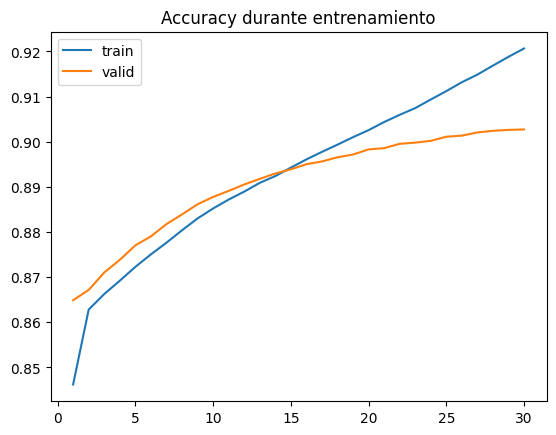

In [18]:
epoch_count = range(1, len(hist.history['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=hist.history['accuracy'],     label='train')
sns.lineplot(x=epoch_count, y=hist.history['val_accuracy'], label='valid')
plt.title("Accuracy durante entrenamiento")
plt.show()

In [19]:
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units):
    """Modelo de encoder que solo devuelve los estados."""
    enc_emb = enc_emb_layer(enc_inputs)                    # reutiliza pesos entrenados
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return Model(enc_inputs, [state_h, state_c])


def build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):
    """Modelo de decoder paso a paso (un token por vez)."""
    dec_input_single = Input(shape=(1,), name='dec_input_single')
    dec_state_h_in   = Input(shape=(n_units,), name='dec_state_h')
    dec_state_c_in   = Input(shape=(n_units,), name='dec_state_c')

    dec_emb_single = dec_emb_layer(dec_input_single)      # reutiliza pesos entrenados
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single,
        initial_state=[dec_state_h_in, dec_state_c_in]
    )
    dec_out = dec_dense_layer(dec_out)

    return Model(
        [dec_input_single, dec_state_h_in, dec_state_c_in],
        [dec_out, h_out, c_out]
    )

In [20]:
encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units)
decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)

idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

Traducciones:

In [21]:
def translate_sentence(input_seq):
    h, c = encoder_model.predict(input_seq, verbose=0)    # desempaqueta directo
    target_seq      = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict(
            [target_seq, h, c], verbose=0                 # estados como args separados
        )
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)


def translate(text):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence(seq)

In [22]:
print("\n--- Ejemplos del dataset ---")
for _ in range(5):
    i    = np.random.randint(len(input_sentences))
    seq  = encoder_input_sequences[i:i+1]
    pred = translate_sentence(seq)
    print(f"EN: {input_sentences[i]}")
    print(f"ES (real): {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred): {pred}\n")

print("--- Frases nuevas ---")
for s in ["My mother says hi.", "Where is the train station?",
          "I love learning languages.", "Can you help me?", "The cat is undet the table"]:
    print(f"EN: {s}")
    print(f"ES: {translate(s)}\n")


--- Ejemplos del dataset ---
EN: Would you prefer to do that today?
ES (real): ¿Preferirías hacerlo hoy?
ES (pred): te gustaría hacer esto

EN: Tom shouted at Mary.
ES (real): Tom le gritó a Mary.
ES (pred): tom le disparó a mary

EN: Tom was probably joking.
ES (real): Probablemente Tom estaba bromeando.
ES (pred): tom estaba bromeando

EN: Tom is Mary's son-in-law.
ES (real): Tom es el yerno de Mary.
ES (pred): tom es el de mary

EN: You're safe now.
ES (real): Ahora estás a salvo.
ES (pred): aquí

--- Frases nuevas ---
EN: My mother says hi.
ES: mi padre me hizo

EN: Where is the train station?
ES: dónde está en el tren

EN: I love learning languages.
ES: me gustan los libros

EN: Can you help me?
ES: puedes ayudarme

EN: The cat is undet the table
ES: el perro está en la mesa



### Modelo 2

- Batch size de 64 para el entrenamiento
- Embeddings de GloVe de dimensión 50
- 512 celdas en la capa LSTM
- Dropout de 0.3
- Learning rate del optimizador Adam de 5e-4

In [23]:
n_units = 512

enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
    nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units
)
dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
    num_words_output, max_out_len, n_units, enc_states
)

model = Model([enc_inputs, dec_inputs], dec_outputs)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
)

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    metrics=['accuracy']
)

hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[lr_scheduler, early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30
    266/Unknown 30s 105ms/step - accuracy: 0.8238 - loss: 2.1544

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


266/266 ━━━━━━━━━━━━━━━━━━━━ 34s 119ms/step - accuracy: 0.8513 - loss: 1.2685 - val_accuracy: 0.8661 - val_loss: 0.9244 - learning_rate: 5.0000e-04
Epoch 2/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 32s 119ms/step - accuracy: 0.8640 - loss: 0.9335 - val_accuracy: 0.8692 - val_loss: 0.8707 - learning_rate: 5.0000e-04
Epoch 3/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 31s 118ms/step - accuracy: 0.8688 - loss: 0.8712 - val_accuracy: 0.8744 - val_loss: 0.8132 - learning_rate: 5.0000e-04
Epoch 4/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 32s 118ms/step - accuracy: 0.8740 - loss: 0.8080 - val_accuracy: 0.8792 - val_loss: 0.7637 - learning_rate: 5.0000e-04
Epoch 5/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 32s 118ms/step - accuracy: 0.8785 - loss: 0.7512 - val_accuracy: 0.8835 - val_loss: 0.7220 - learning_rate: 5.0000e-04
Epoch 6/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 31s 118ms/step - accuracy: 0.8827 - loss: 0.7005 - val_accuracy: 0.8866 - val_loss: 0.6889 - learning_rate: 5.0000e-04
Epoch 7/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 32s 119ms/step - 

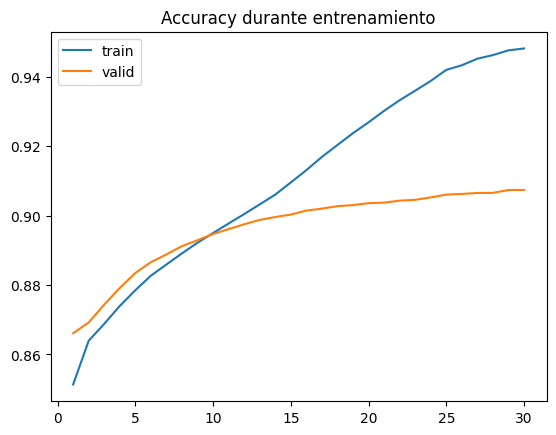

In [24]:
epoch_count = range(1, len(hist.history['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=hist.history['accuracy'],     label='train')
sns.lineplot(x=epoch_count, y=hist.history['val_accuracy'], label='valid')
plt.title("Accuracy durante entrenamiento")
plt.show()

In [25]:
encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units)
decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)

idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

Traducciones:

In [26]:
print("\n--- Ejemplos del dataset ---")
for _ in range(5):
    i    = np.random.randint(len(input_sentences))
    seq  = encoder_input_sequences[i:i+1]
    pred = translate_sentence(seq)
    print(f"EN: {input_sentences[i]}")
    print(f"ES (real): {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred): {pred}\n")

print("--- Frases nuevas ---")
for s in ["My mother says hi.", "Where is the train station?",
          "I love learning languages.", "Can you help me?", "The cat is undet the table"]:
    print(f"EN: {s}")
    print(f"ES: {translate(s)}\n")


--- Ejemplos del dataset ---
EN: I haven't ever seen one of these before.
ES (real): Nunca he visto uno de éstos hasta ahora.
ES (pred): no he visto todas las dos de vez

EN: Tom shook hands with Mary.
ES (real): Tom y Mary se dieron un apretón de manos.
ES (pred): tom se inclinó cortésmente ante su madre

EN: Spring is just around the corner.
ES (real): La primavera está a la vuelta de la esquina.
ES (pred): la primavera está en la puerta

EN: That applies to him too.
ES (real): Eso aplica para él también.
ES (pred): eso le dijo que eso

EN: I became a woman.
ES (real): Me he convertido en mujer.
ES (pred): yo soy una mujer

--- Frases nuevas ---
EN: My mother says hi.
ES: mi padre me va a casar

EN: Where is the train station?
ES: dónde está en la estación

EN: I love learning languages.
ES: me gusta aprender francés

EN: Can you help me?
ES: puedes mostrarme

EN: The cat is undet the table
ES: el gato está el azul



### Modelo 3

- Batch size de 64 para el entrenamiento
- Embeddings de GloVe de dimensión 50
- 256 celdas en la capa LSTM
- Dropout de 0.1
- Learning rate del optimizador Adam de 5e-4

In [27]:
n_units = 256
dropout = 0.1

enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
    nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units, dropout
)
dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
    num_words_output, max_out_len, n_units, enc_states, dropout
)

model = Model([enc_inputs, dec_inputs], dec_outputs)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
)

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    metrics=['accuracy']
)

hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


    266/Unknown 23s 79ms/step - accuracy: 0.8189 - loss: 2.8904

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


266/266 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step - accuracy: 0.8467 - loss: 1.5396 - val_accuracy: 0.8649 - val_loss: 0.9372 - learning_rate: 5.0000e-04
Epoch 2/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 24s 90ms/step - accuracy: 0.8633 - loss: 0.9529 - val_accuracy: 0.8676 - val_loss: 0.8992 - learning_rate: 5.0000e-04
Epoch 3/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 24s 91ms/step - accuracy: 0.8660 - loss: 0.9107 - val_accuracy: 0.8711 - val_loss: 0.8603 - learning_rate: 5.0000e-04
Epoch 4/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 24s 91ms/step - accuracy: 0.8696 - loss: 0.8675 - val_accuracy: 0.8737 - val_loss: 0.8242 - learning_rate: 5.0000e-04
Epoch 5/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 73s 275ms/step - accuracy: 0.8728 - loss: 0.8263 - val_accuracy: 0.8768 - val_loss: 0.7904 - learning_rate: 5.0000e-04
Epoch 6/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 24s 89ms/step - accuracy: 0.8758 - loss: 0.7877 - val_accuracy: 0.8801 - val_loss: 0.7590 - learning_rate: 5.0000e-04
Epoch 7/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 24s 90ms/step - accura

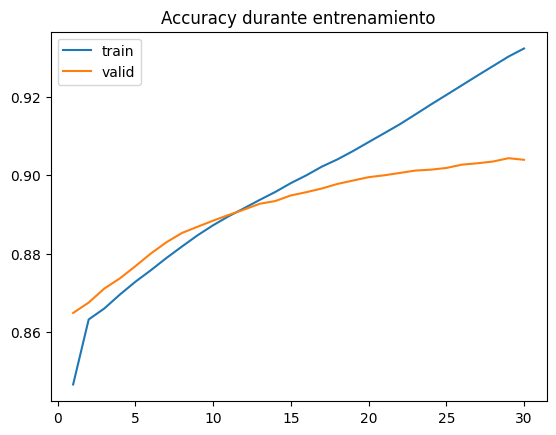

In [28]:
epoch_count = range(1, len(hist.history['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=hist.history['accuracy'],     label='train')
sns.lineplot(x=epoch_count, y=hist.history['val_accuracy'], label='valid')
plt.title("Accuracy durante entrenamiento")
plt.show()

In [29]:
encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units)
decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)

idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

Traducciones:

In [30]:
print("\n--- Ejemplos del dataset ---")
for _ in range(5):
    i    = np.random.randint(len(input_sentences))
    seq  = encoder_input_sequences[i:i+1]
    pred = translate_sentence(seq)
    print(f"EN: {input_sentences[i]}")
    print(f"ES (real): {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred): {pred}\n")

print("--- Frases nuevas ---")
for s in ["My mother says hi.", "Where is the train station?",
          "I love learning languages.", "Can you help me?", "The cat is undet the table"]:
    print(f"EN: {s}")
    print(f"ES: {translate(s)}\n")


--- Ejemplos del dataset ---
EN: He wants to go.
ES (real): Quiere ir.
ES (pred): él quiere ir

EN: My watch has been stolen.
ES (real): Me han robado el reloj.
ES (pred): mi reloj ha visto en japón

EN: What's the trouble? Can I be of any help?
ES (real): ¿Cuál es el problema? ¿Puedo ayudar en algo?
ES (pred): la gente puede ser capaz de ti

EN: Start singing.
ES (real): Comenzad a cantar.
ES (pred): de quién está hablando

EN: Japan imports oranges from California.
ES (real): Japón importa naranjas desde California.
ES (pred): los precios de los árboles de nieve

--- Frases nuevas ---
EN: My mother says hi.
ES: mi padre le gusta la noche

EN: Where is the train station?
ES: dónde está en la estación

EN: I love learning languages.
ES: me encantan los libros

EN: Can you help me?
ES: puedes ayudarme

EN: The cat is undet the table
ES: el gato está en la mesa



Se puede observar que la calidad de las traducciones no es perfecta para ninguno de los modelos entrenados, aunque se pueden percibir mejoras significativas con respecto al traductor realizado en clase, duplicando el dataset se obtuvieron modelos que sí aciertan gran parte de las palabras de las oraciones.

Haber duplicado el número de celdas LSTM no produjo una mejora significativa en las traducciones (Modelo 2 vs Modelo 1), en cambio en el gráfico de accuracy de ambos modelos se observa que esto produjo un overfitting a los datos de train.

En cambio al reducir el dropout (Modelo 3) en los ejemplos acierta algunas palabras más con respecto al modelo 1 y en su gráfico de accuracy no se observa un mayor overfitting a los datos de train.
